# **Analyse et Ingénierie des données de la chlordécone aux Antilles françaises**

## Notebook 4 – Analyses Statistiques

Dans ce notebook on va analyser les relations entre le taux de chlordécone et les différentes variables du jeu de données (type de sol, pluviométrie, topographie...) et regarder l'évolution dans le temps.

### Objectifs de ce notebook
- Calculer et visualiser les corrélations entre variables numériques
- Analyser le taux de chlordécone selon le type de sol, la pluviométrie et la topographie
- Étudier l'évolution temporelle (2010–2019)
- Vérifier la normalité des distributions et appliquer les tests statistiques adaptés
- Appliquer une régression linéaire et un modèle de machine learning (Random Forest)
- Sauvegarder les figures pour le reporting final

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

NOTEBOOK_DIR = os.getcwd()
FIG_DIR = os.path.join(NOTEBOOK_DIR, 'fig', '4-analyses_statistiques')
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_csv(
    os.path.join(NOTEBOOK_DIR, 'BaseCLD2026.csv'),
    sep=';',  # ← séparateur point-virgule
    parse_dates=['Date_prelevement', 'Date_enregistrement', 'Date_analyse']
)

df['log_Taux'] = np.log1p(df['Taux_Chlordecone'])
print(df.shape)
print(df.head(2))

(31126, 23)
      ID  ANNEE   COMMU_LAB       RAIN Sol_simple  \
0  20143   2010  GROS-MORNE  2000-3000    Andosol   
1  20143   2010  GROS-MORNE  2000-3000    Andosol   

                                            type_sol Date_prelevement  \
0  Intergrades Sols … allophane relativement ‚vol...       2007-05-24   
1  Intergrades Sols … allophane relativement ‚vol...       2007-05-24   

  Date_enregistrement Date_analyse Operateur_chld  ...  histoBanane_Histo_ban  \
0          2007-05-24   2007-05-24              =  ...                    2.0   
1          2007-05-24   2007-05-24              =  ...                    2.0   

  mnt_tpi_mean mnt_tri_mean  mnt_rugosite_mean  mnt_ombrage_mean  \
0     5.805967     8.033367          21.593658        131.173998   
1     5.683589     7.920563          20.944901        134.608205   

   mnt_exposition_mean  mnt_pente_mean              X             Y  log_Taux  
0            79.447954       39.043098  714300.831892  1.626344e+06  1.722767  

C:\Users\patxi\AppData\Local\Temp\ipykernel_16624\3950933716.py:12: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(
C:\Users\patxi\AppData\Local\Temp\ipykernel_16624\3950933716.py:12: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(
C:\Users\patxi\AppData\Local\Temp\ipykernel_16624\3950933716.py:12: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(


## 1. Matrice de corrélations

On commence par regarder les corrélations entre toutes les variables numériques pour avoir une vue d'ensemble.

In [13]:
# Diagnostic : voir les vraies valeurs brutes
df_raw = pd.read_csv(
    os.path.join(NOTEBOOK_DIR, 'BaseCLD2026.csv'),
    sep=';'
)
print(df_raw['Taux_Chlordecone'].dtype)
print(df_raw['Taux_Chlordecone'].head(10).tolist())

float64
[4.6, 4.6, 4.6, 4.6, 4.6, 4.6, 4.6, 0.0033, 0.0033, 0.0033]


In [18]:
cols_numeriques = ['Taux_Chlordecone', 'Taux_5b_hydro', 'histoBanane_Histo_ban',
                   'mnt_tpi_mean', 'mnt_tri_mean', 'mnt_rugosite_mean',
                   'mnt_ombrage_mean', 'mnt_exposition_mean', 'mnt_pente_mean']

for col in cols_numeriques:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df[cols_numeriques].dtypes)

Taux_Chlordecone         float64
Taux_5b_hydro            float64
histoBanane_Histo_ban    float64
mnt_tpi_mean             float64
mnt_tri_mean             float64
mnt_rugosite_mean        float64
mnt_ombrage_mean         float64
mnt_exposition_mean      float64
mnt_pente_mean           float64
dtype: object


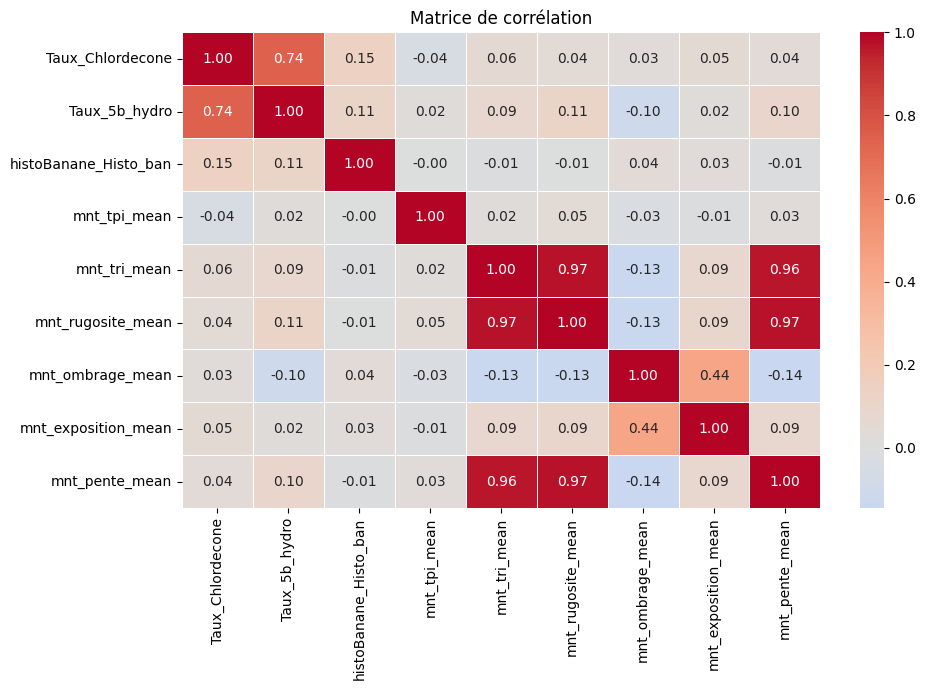

In [20]:
corr = df[num_cols].corr() # Calcul de la matrice de corrélation pour les colonnes numériques sélectionnées

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5) # Affichage de la matrice de corrélation sous forme de Heatmap
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()

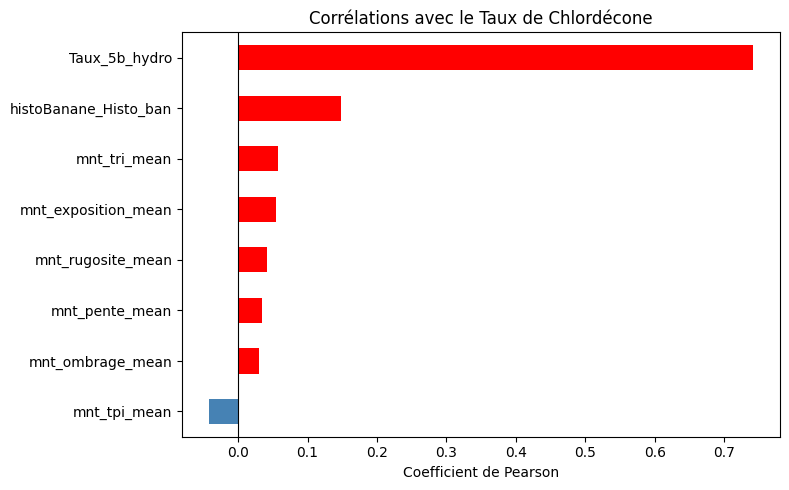

In [21]:
# Corrélations avec le taux de chlordécone uniquement
corr_cible = corr['Taux_Chlordecone'].drop('Taux_Chlordecone').sort_values()

plt.figure(figsize=(8, 5))
corr_cible.plot(kind='barh', color=['red' if v > 0 else 'steelblue' for v in corr_cible])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Corrélations avec le Taux de Chlordécone')
plt.xlabel('Coefficient de Pearson')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_correlations_cible.png'), dpi=150, bbox_inches='tight')
plt.show()

## 1.bis Vérification de la normalité

Avant d'appliquer des tests statistiques, on vérifie si la distribution du taux de chlordécone suit une loi normale. Cela conditionne le choix entre tests paramétriques (ANOVA, t-test) et non-paramétriques (Kruskal-Wallis, Mann-Whitney).

In [23]:
# Création de la colonne log_Taux (à faire après la conversion numérique)
df['log_Taux'] = np.log1p(df['Taux_Chlordecone'])

Shapiro-Wilk : W = 0.5061, p-value = 6.95e-80
→ Distribution NON normale (p < 0.05) : on utilisera des tests non-paramétriques.


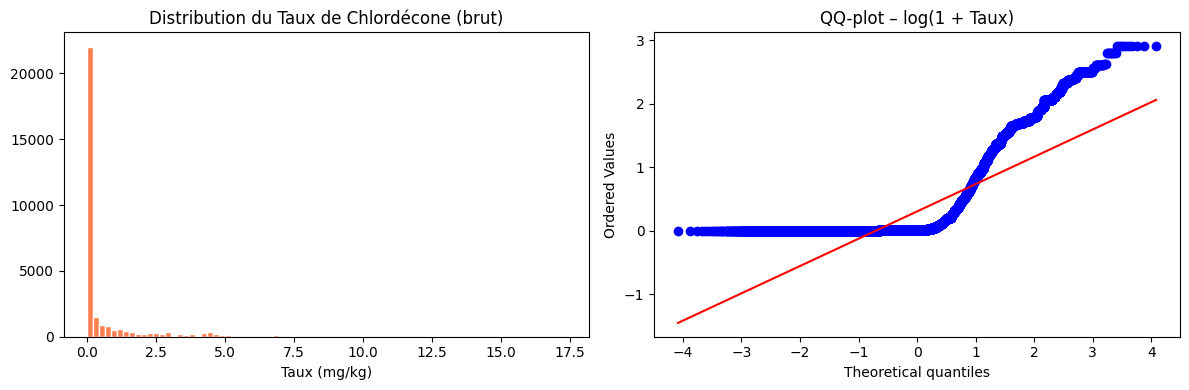

In [24]:
# Test de Shapiro-Wilk sur un échantillon (limité à 5000 obs. car le test est lent sur grands jeux de données)
sample = df['Taux_Chlordecone'].dropna().sample(n=min(5000, len(df)), random_state=42)
stat, p_shapiro = stats.shapiro(sample)
print(f'Shapiro-Wilk : W = {stat:.4f}, p-value = {p_shapiro:.2e}')
if p_shapiro < 0.05:
    print('→ Distribution NON normale (p < 0.05) : on utilisera des tests non-paramétriques.')
else:
    print('→ Distribution normale (p ≥ 0.05) : tests paramétriques applicables.')

# QQ-plot pour visualiser l'écart à la normalité
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Taux_Chlordecone'].dropna(), bins=80, color='coral', edgecolor='white')
axes[0].set_title('Distribution du Taux de Chlordécone (brut)')
axes[0].set_xlabel('Taux (mg/kg)')

stats.probplot(df['log_Taux'].dropna(), dist='norm', plot=axes[1])
axes[1].set_title('QQ-plot – log(1 + Taux)')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_normalite_qqplot.png'), dpi=150, bbox_inches='tight')
plt.show()

## 2. Taux de chlordécone par type de sol

On s'attend à ce que le type de sol joue un rôle important dans la rétention du chlordécone.

In [25]:
# Statistiques par type de sol
df.groupby('Sol_simple')['Taux_Chlordecone'].agg(['mean', 'median', 'std', 'count']).round(3).sort_values('mean', ascending=False) # Affichage des statistiques descriptives du taux de chlordécone par type de sol, triées par moyenne décroissante

,mean,median,std,count
Sol_simple,,,,
Andosol,1.242,0.090,2.094,10953
No data,1.152,0.020,2.092,2617
"Alluvium, Colluvium",0.411,0.057,0.794,1604
Nitisol,0.320,0.003,0.918,3063
Urban area,0.313,0.003,1.048,712
Ferralsol,0.208,0.003,0.648,5182
Vertisol,0.164,0.003,0.528,6921


C:\Users\patxi\AppData\Local\Temp\ipykernel_16624\39645301.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sol, x='Sol_simple', y='log_Taux', palette='Set2')


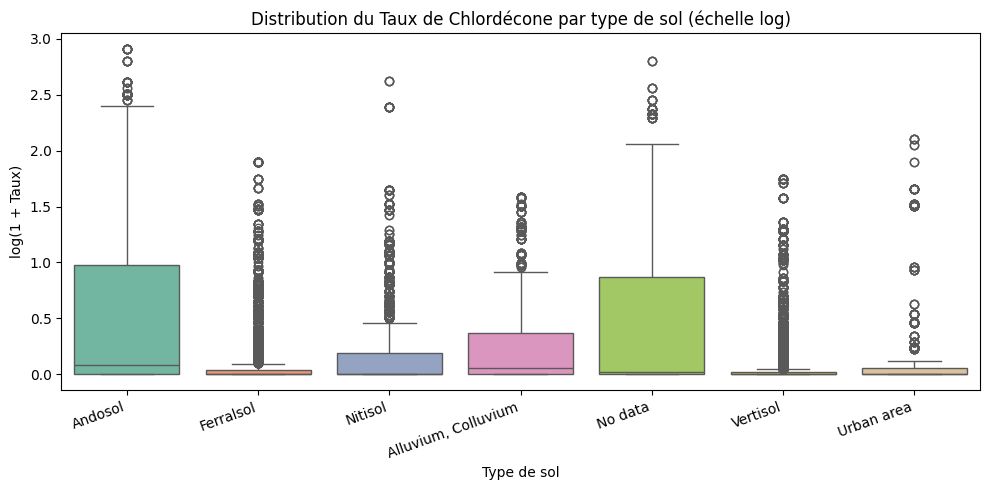

In [26]:
df_sol = df[df['Sol_simple'].notna()]

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_sol, x='Sol_simple', y='log_Taux', palette='Set2')
plt.title('Distribution du Taux de Chlordécone par type de sol (échelle log)')
plt.xlabel('Type de sol')
plt.ylabel('log(1 + Taux)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_boxplot_sol.png'), dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# Test de Kruskal-Wallis pour savoir si les différences entre sols sont significatives
# On utilise Kruskal-Wallis plutôt que ANOVA car la distribution n'est pas normale
groupes = [g['Taux_Chlordecone'].dropna().values for _, g in df.groupby('Sol_simple')] # On crée une liste de tableaux de taux de chlordécone pour chaque type de sol

h, p = stats.kruskal(*groupes) # Test de Kruskal-Wallis pour comparer les distributions entre les groupes
print(f'Kruskal-Wallis : H = {h:.2f}, p-value = {p:.2e}') # Affichage des résultats

if p < 0.05:
    print('-> Les différences entre types de sol sont statistiquement significatives.') # Car la p-value est inférieure à 0.05, on rejette l'hypothèse nulle d'égalité des distributions
else:
    print('-> Pas de différence significative entre les types de sol.')

Kruskal-Wallis : H = 4628.21, p-value = 0.00e+00
-> Les différences entre types de sol sont statistiquement significatives.


## 3. Taux de chlordécone par pluviométrie

In [28]:
rain_order = ['0-1250', '1250-1500', '1500-2000', '2000-3000', '3000-5000', '5000-8000'] # Ordre des catégories de pluie 

# On utilise un "groupby" pour calculer les statistiques descriptives du taux de chlordécone par catégorie de pluie (3 chiffres significatifs)
stats_rain = df.groupby('RAIN')['Taux_Chlordecone'].agg(['mean', 'median', 'count']).reindex(rain_order).round(3)
stats_rain

,mean,median,count
RAIN,,,
0-1250,0.014,0.003,312
1250-1500,0.048,0.003,1490
1500-2000,0.169,0.003,7658
2000-3000,0.763,0.012,17425
3000-5000,1.473,0.169,4149
5000-8000,0.003,0.003,92


C:\Users\patxi\AppData\Local\Temp\ipykernel_16624\3362452531.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='RAIN', y='log_Taux', order=rain_order, palette='Blues', ax=axes[0])


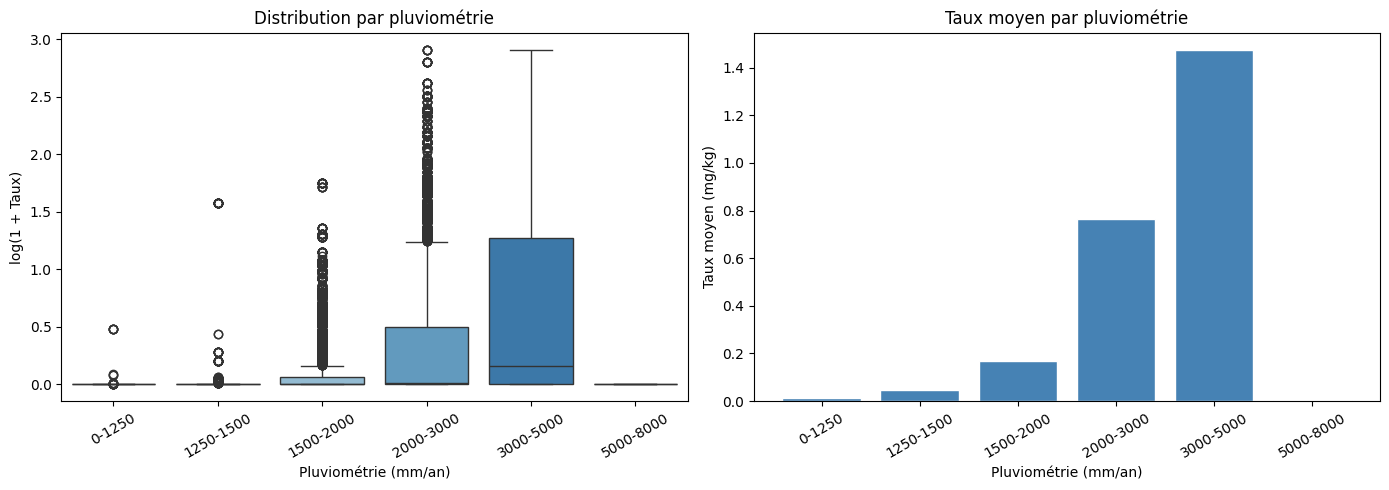

In [29]:
rain_order = ['0-1250', '1250-1500', '1500-2000', '2000-3000', '3000-5000', '5000-8000']
stats_rain = df.groupby('RAIN')['Taux_Chlordecone'].agg(['mean', 'median', 'count']).reindex(rain_order).round(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='RAIN', y='log_Taux', order=rain_order, palette='Blues', ax=axes[0])
axes[0].set_title('Distribution par pluviométrie')
axes[0].set_xlabel('Pluviométrie (mm/an)')
axes[0].set_ylabel('log(1 + Taux)')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(stats_rain.index, stats_rain['mean'], color='steelblue', edgecolor='white')
axes[1].set_title('Taux moyen par pluviométrie')
axes[1].set_xlabel('Pluviométrie (mm/an)')
axes[1].set_ylabel('Taux moyen (mg/kg)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_boxplot_pluie.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Évolution temporelle (2010–2019)

In [30]:
# Statistiques du taux de chlordécone par année
agg_annee = df.groupby('ANNEE')['Taux_Chlordecone'].agg(['mean', 'median', 'count']).reset_index()
agg_annee

,ANNEE,mean,median,count
0,2010,2.778224,2.6500,3928
1,2011,1.389427,0.1100,1163
2,2012,0.495438,0.0200,1479
3,2013,0.368191,0.0033,1562
4,2014,0.369660,0.0800,1153
5,2015,0.520433,0.0033,3158
6,2016,0.219061,0.0033,4316
7,2017,0.529069,0.0060,5141
8,2018,0.111959,0.0020,8567
9,2019,0.380453,0.1160,659


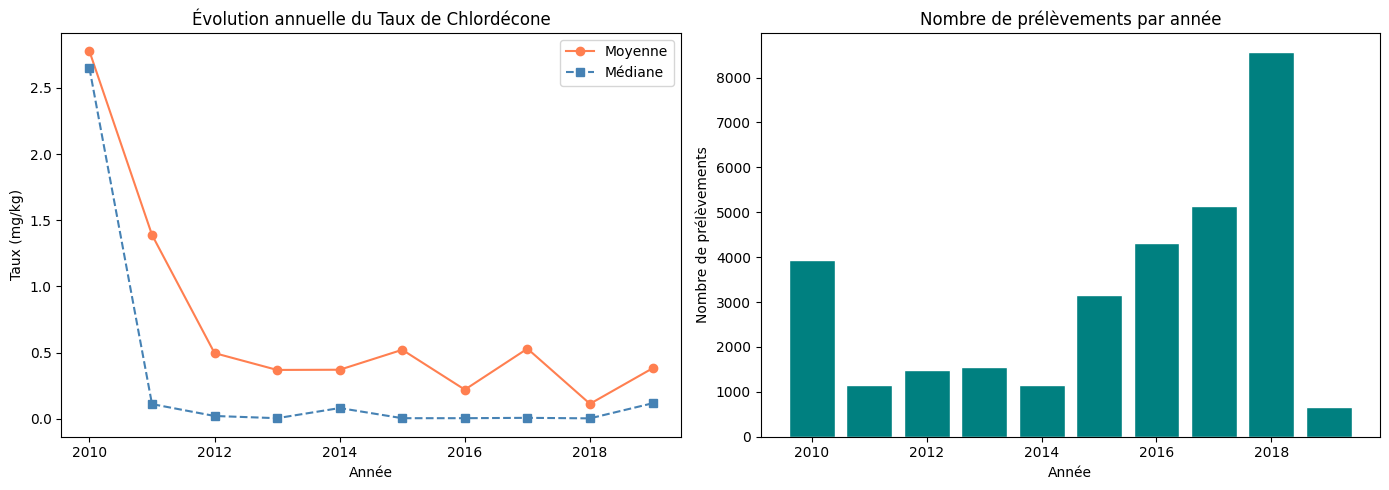

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(agg_annee['ANNEE'], agg_annee['mean'],   marker='o', color='coral',     label='Moyenne')
axes[0].plot(agg_annee['ANNEE'], agg_annee['median'], marker='s', linestyle='--', color='steelblue', label='Médiane')
axes[0].set_title('Évolution annuelle du Taux de Chlordécone')
axes[0].set_xlabel('Année')
axes[0].set_ylabel('Taux (mg/kg)')
axes[0].legend()

axes[1].bar(agg_annee['ANNEE'], agg_annee['count'], color='teal', edgecolor='white')
axes[1].set_title('Nombre de prélèvements par année')
axes[1].set_xlabel('Année')
axes[1].set_ylabel('Nombre de prélèvements')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_evolution_temporelle.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Impact de l'historique bananier

Les parcelles qui ont eu des cultures de bananes sont potentiellement plus exposées car le chlordécone était massivement utilisé dans les bananeraies.

Effectifs par groupe :
histo_label
Avec historique bananier    13143
Name: count, dtype: int64

→ Un seul groupe présent : analyse comparative impossible, on se limite à la description.


C:\Users\patxi\AppData\Local\Temp\ipykernel_16624\2996516673.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_banane, x='histo_label', y='log_Taux', palette=['#27ae60', '#e74c3c'])
C:\Users\patxi\AppData\Local\Temp\ipykernel_16624\2996516673.py:26: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.boxplot(data=df_banane, x='histo_label', y='log_Taux', palette=['#27ae60', '#e74c3c'])


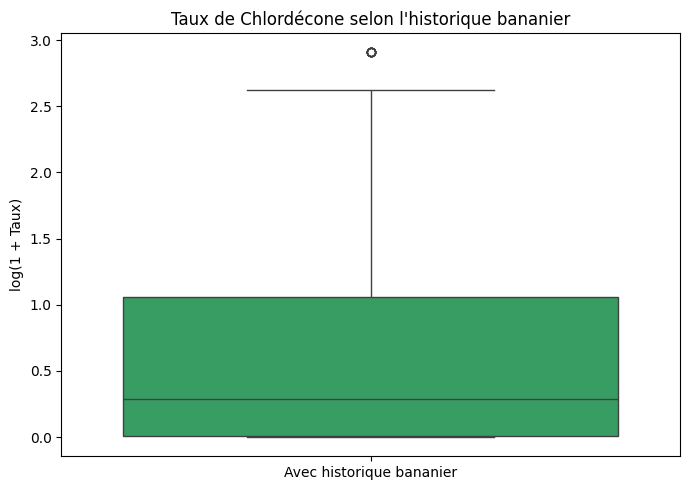

In [32]:
# Analyse de l'impact de l'historique bananier sur le taux de chlordécone
df_banane = df[df['histoBanane_Histo_ban'].notna()].copy()
df_banane['histo_label'] = df_banane['histoBanane_Histo_ban'].apply(
    lambda x: 'Avec historique bananier' if x > 0 else 'Sans historique bananier'
)

# Vérification des effectifs dans chaque groupe
effectifs = df_banane['histo_label'].value_counts()
print('Effectifs par groupe :')
print(effectifs)

# Si les deux groupes sont présents, on peut comparer ; sinon on décrit uniquement
if effectifs.shape[0] == 2:
    avec = df_banane[df_banane['histo_label'] == 'Avec historique bananier']['Taux_Chlordecone']
    sans = df_banane[df_banane['histo_label'] == 'Sans historique bananier']['Taux_Chlordecone']
    u, p = stats.mannwhitneyu(avec, sans, alternative='two-sided')
    print(f'\nMann-Whitney : U = {u:.0f}, p-value = {p:.2e}')
    if p < 0.05:
        print('→ L\'historique bananier a un impact significatif sur le taux de chlordécone.')
    else:
        print('→ Pas de différence significative entre les deux groupes (p ≥ 0.05).')
else:
    print('\n→ Un seul groupe présent : analyse comparative impossible, on se limite à la description.')

plt.figure(figsize=(7, 5))
sns.boxplot(data=df_banane, x='histo_label', y='log_Taux', palette=['#27ae60', '#e74c3c'])
plt.title('Taux de Chlordécone selon l\'historique bananier')
plt.xlabel('')
plt.ylabel('log(1 + Taux)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_bananier.png'), dpi=150, bbox_inches='tight')
plt.show()

Le test Mann-Whitney est appliqué **conditionnellement** à la présence des deux groupes dans les données. Si la colonne `histoBanane_Histo_ban` ne contient que des parcelles avec historique bananier, on se limite à l'analyse descriptive.

In [33]:
# Affichage des statistiques descriptives du taux de chlordécone pour les échantillons avec historique bananier (données complètes)
print(df_banane.groupby('histo_label')['Taux_Chlordecone'].describe())

                            count      mean       std    min     25%   50%  \
histo_label                                                                  
Avec historique bananier  13143.0  1.292643  1.992948  0.001  0.0058  0.33   

                            75%    max  
histo_label                             
Avec historique bananier  1.883  17.35  


## 6. Variables topographiques vs Taux de chlordécone

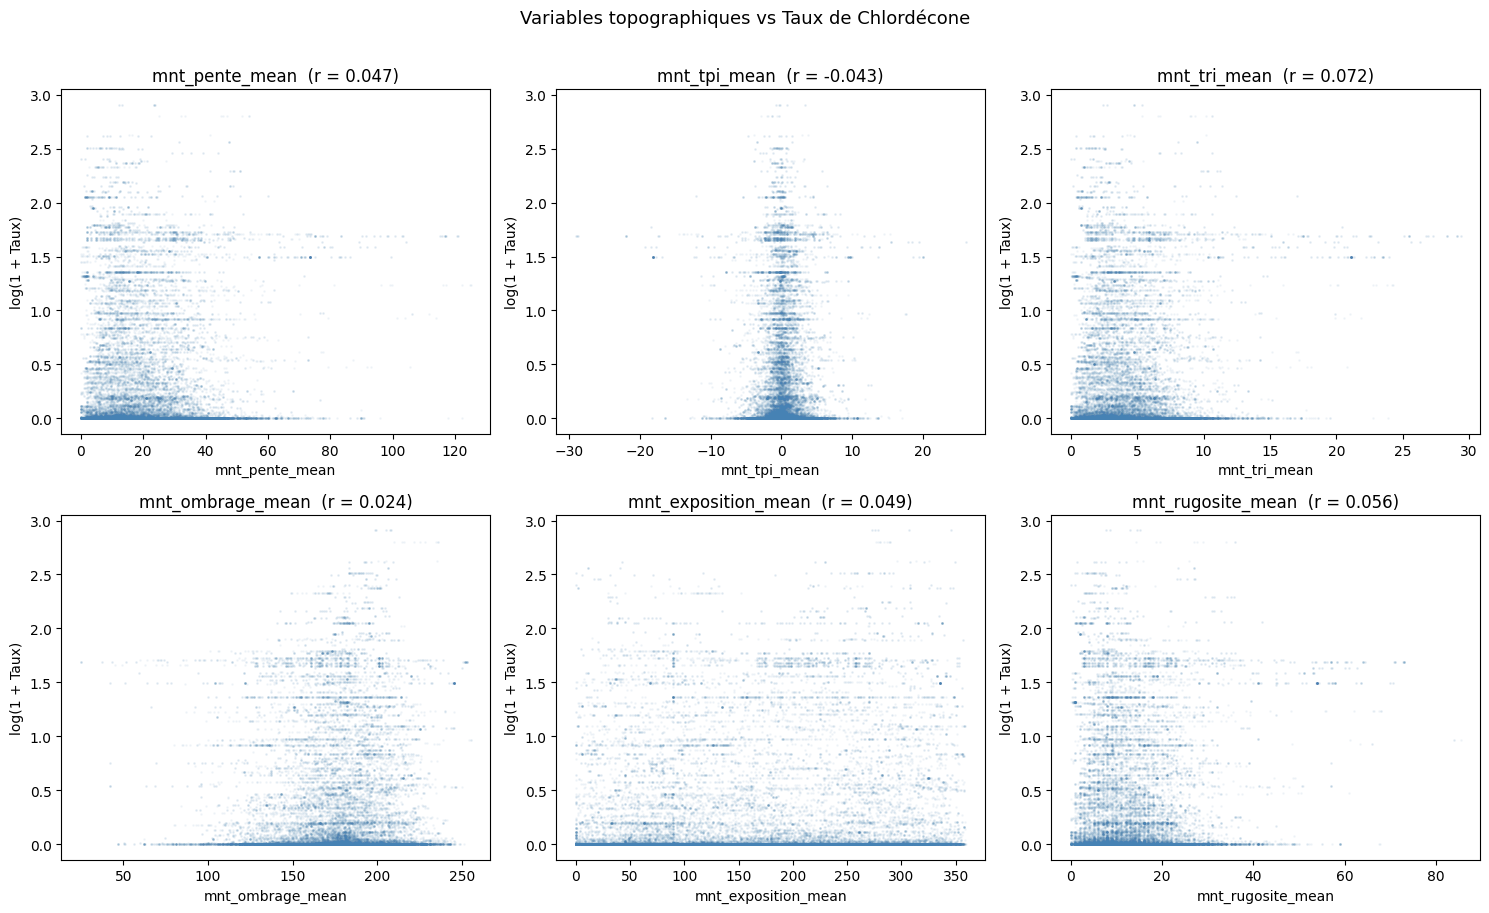

In [34]:
topo_cols = ['mnt_pente_mean', 'mnt_tpi_mean', 'mnt_tri_mean',
             'mnt_ombrage_mean', 'mnt_exposition_mean', 'mnt_rugosite_mean']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(topo_cols):
    axes[i].scatter(df[col], df['log_Taux'], alpha=0.05, s=1, color='steelblue')
    r = df[col].corr(df['log_Taux'])
    axes[i].set_title(f'{col}  (r = {r:.3f})')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('log(1 + Taux)')

plt.suptitle('Variables topographiques vs Taux de Chlordécone', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_topo_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Régression linéaire – Facteurs explicatifs du taux de chlordécone

On cherche à quantifier la relation entre `log_Taux` (variable cible) et les variables explicatives disponibles (pente, pluviométrie ordinale, type de sol encodé). La régression linéaire multiple permet d'estimer l'effet propre de chaque variable, toutes choses égales par ailleurs.

R² (test)  : 0.1086
MAE (test) : 0.3797


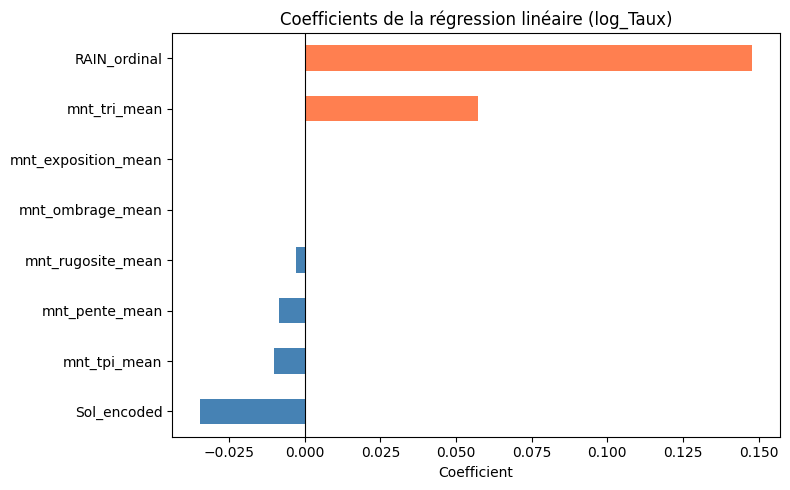

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

# Préparation des features : variables numériques disponibles
features = ['mnt_pente_mean', 'mnt_tpi_mean', 'mnt_tri_mean',
            'mnt_ombrage_mean', 'mnt_exposition_mean', 'mnt_rugosite_mean']

# Recodage ordinal de la pluviométrie (comme dans le notebook 3)
rain_order = {'0-1250':1, '1250-1500':2, '1500-2000':3,
              '2000-3000':4, '3000-5000':5, '5000-8000':6}
df['RAIN_ordinal'] = df['RAIN'].map(rain_order)
features.append('RAIN_ordinal')

# Encodage du type de sol (Label Encoding)
le = LabelEncoder()
df['Sol_encoded'] = le.fit_transform(df['Sol_simple'].astype(str))
features.append('Sol_encoded')

# Sous-ensemble sans valeurs manquantes
df_reg = df[features + ['log_Taux']].dropna()
X = df_reg[features]
y = df_reg['log_Taux']

# Découpage train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ajustement du modèle
reg = LinearRegression()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

print(f'R² (test)  : {r2_score(y_test, y_pred):.4f}')
print(f'MAE (test) : {mean_absolute_error(y_test, y_pred):.4f}')

# Coefficients du modèle
coefs = pd.Series(reg.coef_, index=features).sort_values()
plt.figure(figsize=(8, 5))
coefs.plot(kind='barh', color=['coral' if v > 0 else 'steelblue' for v in coefs])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coefficients de la régression linéaire (log_Taux)')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_regression_coefs.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Machine Learning – Random Forest (feature importance)

Un modèle de forêt aléatoire permet d'identifier les variables les plus importantes pour expliquer le taux de chlordécone, sans hypothèse de linéarité.

Random Forest – R² (test)  : 0.5212
Random Forest – MAE (test) : 0.2336


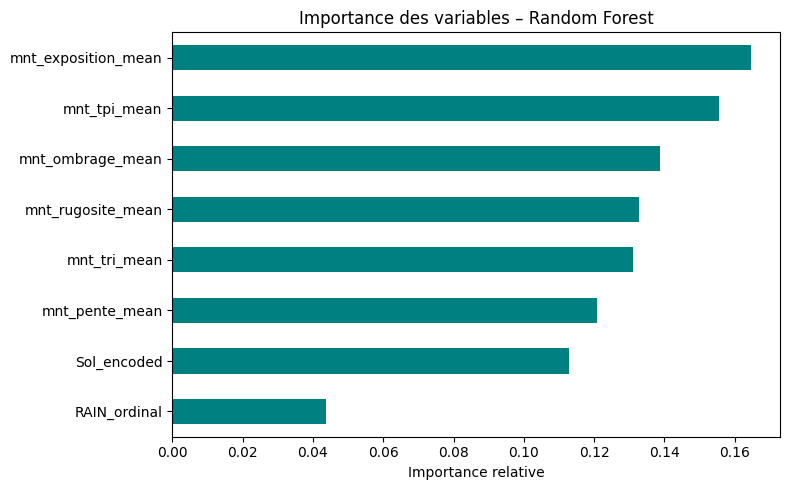


=== Comparaison des modèles ===
  Régression linéaire – R² : 0.1086
  Random Forest       – R² : 0.5212


In [41]:
from sklearn.ensemble import RandomForestRegressor

# Même jeu de données que pour la régression
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f'Random Forest – R² (test)  : {r2_score(y_test, y_pred_rf):.4f}')
print(f'Random Forest – MAE (test) : {mean_absolute_error(y_test, y_pred_rf):.4f}')

# Importance des variables
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='teal')
plt.title('Importance des variables – Random Forest')
plt.xlabel('Importance relative')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_rf_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

# Comparaison Régression Linéaire vs Random Forest
print('\n=== Comparaison des modèles ===')
print(f'  Régression linéaire – R² : {r2_score(y_test, y_pred):.4f}')
print(f'  Random Forest       – R² : {r2_score(y_test, y_pred_rf):.4f}')

## Synthèse

Ce notebook a permis de :
- Identifier les variables les plus corrélées au taux de chlordécone (matrice de Pearson)
- Confirmer statistiquement les différences entre types de sol (Kruskal-Wallis) et groupes (Mann-Whitney)
- Justifier l'usage de tests non-paramétriques via le test de Shapiro-Wilk et le QQ-plot
- Quantifier l'effet des variables explicatives via une régression linéaire multiple
- Identifier les variables les plus importantes via un Random Forest

Ces analyses alimenteront la synthèse finale orientée aide à la décision.